In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
data = pd.read_csv("./winning_deck_results.csv", index_col=0)
# Turn the won column into boolean
data['won'] = data['won'].map({' True': True, " False": False})
data.head()

,num_moves,won,x0,x1,x2,x3,x4,x5,x6,x7,...,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51
deck,,,,,,,,,,,,,,,,,,,,,
0,138,True,29,13,46,42,39,8,6,37,...,31,20,26,32,33,17,3,27,49,25
1,21,False,50,10,38,23,3,39,20,12,...,42,31,29,32,8,17,5,49,37,9
2,43,False,16,30,10,22,5,7,52,27,...,14,39,17,20,43,11,24,51,6,4
3,2,False,14,29,4,20,30,27,52,23,...,5,51,41,31,39,24,9,35,38,16
4,23,False,38,23,40,22,17,52,29,51,...,2,5,6,10,31,26,47,7,20,16


In [2]:
visible_cards = data.iloc[:, [2, 9, 17, 20, 24, 27, 29]]
deck_cards = data.iloc[:, 30:]
known_cards = pd.concat([visible_cards, deck_cards], axis=1)
known_cards.columns = range(known_cards.shape[1])
known_cards.head()

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
deck,,,,,,,,,,,,,,,,,,,,,
0,29,37,15,35,43,11,28,51,24,4,...,31,20,26,32,33,17,3,27,49,25
1,50,12,47,41,33,27,11,34,4,19,...,42,31,29,32,8,17,5,49,37,9
2,16,27,31,21,47,15,1,40,2,34,...,14,39,17,20,43,11,24,51,6,4
3,14,23,49,2,22,44,28,43,21,8,...,5,51,41,31,39,24,9,35,38,16
4,38,51,13,33,30,42,27,1,32,9,...,2,5,6,10,31,26,47,7,20,16


<Axes: xlabel='won', ylabel='num_moves'>

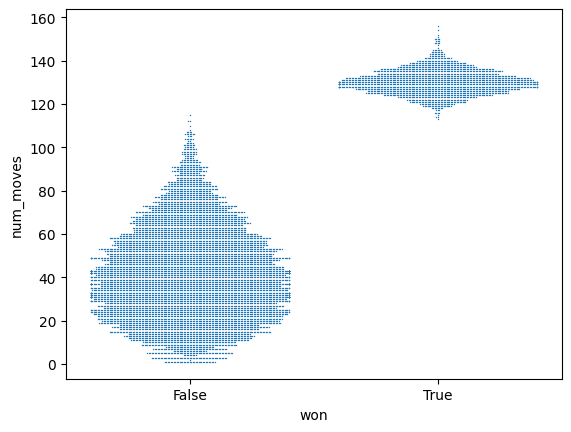

In [3]:
# Do not set size greater than 1. It can't display all points if higher
sns.swarmplot(x=data['won'], y=data['num_moves'], size=1)

In [4]:
max_loss = data.loc[data['won'] == False, 'num_moves'].max()
min_win = data.loc[data['won'] == True, 'num_moves'].min()
print("Maximum moves to loss:", max_loss, " | Minimum moves to win:", min_win)

Maximum moves to loss: 115  | Minimum moves to win: 113


In [5]:
data = data.iloc[:, 2:].fillna(0)

card_ids = data.values.astype(int)

mask = card_ids > 0

card_ids_adj = np.where(mask, card_ids - 1, 0)

suits = card_ids_adj // 13
ranks = (card_ids_adj % 13)

colors = np.where(suits < 2, 0, 1)

# handle unknowns
ranks[~mask] = 0
suits[~mask] = -1
colors[~mask] = -1

cols = []
for i, col in enumerate(data.columns):
    cols.append(pd.DataFrame({
        f"{col}_rank": ranks[:, i],
        f"{col}_suit": suits[:, i],
        f"{col}_color": colors[:, i],
    }))

remapped = pd.concat(cols, axis=1)
remapped.head()

,x0_rank,x0_suit,x0_color,x1_rank,x1_suit,x1_color,x2_rank,x2_suit,x2_color,x3_rank,...,x48_color,x49_rank,x49_suit,x49_color,x50_rank,x50_suit,x50_color,x51_rank,x51_suit,x51_color
0,2,2,1,12,0,0,6,3,1,2,...,0,0,2,1,9,3,1,11,1,0
1,10,3,1,9,0,0,11,2,1,9,...,0,9,3,1,10,2,1,8,0,0
2,2,1,0,3,2,1,9,0,0,8,...,0,11,3,1,5,0,0,3,0,0
3,0,1,0,2,2,1,3,0,0,6,...,0,8,2,1,11,2,1,2,1,0
4,11,2,1,9,1,0,0,3,1,8,...,1,6,0,0,6,1,0,2,1,0


In [6]:
def count_valid_moves(ranks, colors):
    moves = 0
    n = len(ranks)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            if (
                ranks[i] > 0 and ranks[j] > 0 and
                colors[i] != colors[j] and
                ranks[i] == ranks[j] - 1
            ):
                moves += 1

    return moves
move_counts = []

for row in range(ranks.shape[0]):
    move_counts.append(count_valid_moves(ranks[row], colors[row]))

remapped["num_valid_moves"] = move_counts

In [7]:
from sklearn.preprocessing import StandardScaler as StdS
from sklearn.linear_model import LogisticRegression as LReg
from sklearn.neural_network import MLPClassifier as MLP
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier as GPC
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier as DTree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.model_selection import cross_val_score
from alive_progress import alive_bar
from sklearn.preprocessing import LabelEncoder as le

In [8]:
X = remapped.values
y = data.iloc[:, 1].astype(int)
sc = StdS()
sc.fit(X)
X_sc = sc.transform(X)

In [9]:
import numpy as np
print(np.mean(y))

26.4141


# K Nearest Neighbors
Change `folds_to_test` and `neighbors_to_test` to modify the tests

|████████████████████████████████████████| 128/128 [100%] in 1:04.8 (1.97/s)    
     Neighbors  Accuracy  Standard Deviation
0          3.0    0.0366            0.004499
1          4.0    0.0354            0.004386
2          5.0    0.0341            0.003145
3          6.0    0.0361            0.003646
4          7.0    0.0370            0.004858
..         ...       ...                 ...
123      126.0    0.0723            0.008695
124      127.0    0.0729            0.008837
125      128.0    0.0733            0.008556
126      129.0    0.0727            0.009675
127      130.0    0.0735            0.009770

[128 rows x 3 columns]
        Neighbors    Accuracy  Standard Deviation
count  128.000000  128.000000          128.000000
mean    66.500000    0.060227            0.007136
std     37.094474    0.009474            0.001898
min      3.000000    0.034100            0.003145
25%     34.750000    0.054900            0.005545
50%     66.500000    0.063800            0.007071
75%  

<Axes: xlabel='Neighbors', ylabel='Accuracy'>

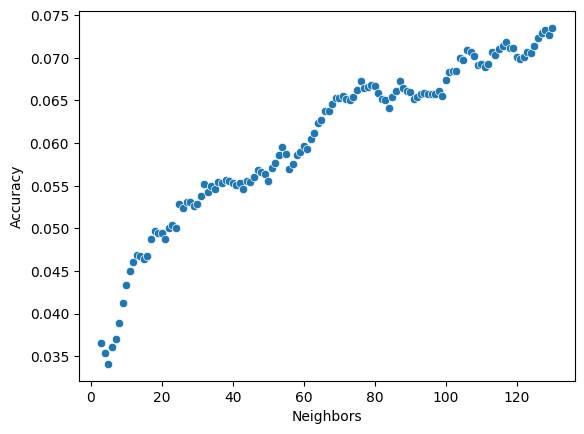

In [10]:
neighbors_to_test: int = 128
# K Nearest Neighbors Test
knn_results = pd.DataFrame(columns=['Neighbors', 'Accuracy', 'Standard Deviation'])
# Test different folds
with alive_bar(neighbors_to_test, force_tty=True) as bar:
    # Test different neighbors
    for i in range(3, neighbors_to_test+3):
        cvs = cross_val_score(KNN(i), X_sc, y, cv=10, n_jobs=-1)
        mean: float = float(np.mean(cvs))
        std: float = float(np.std(cvs))
        knn_results.loc[len(knn_results)] = [i, mean, std]
        bar()
print(knn_results)
print(knn_results.describe())
print(knn_results.iloc[[int(knn_results['Accuracy'].idxmax())]])
sns.scatterplot(knn_results,x='Neighbors', y='Accuracy')

# Linear SVC
Add or remove from `tests_to_run` to change the number of tests

|████████████████████████████████████████| 6/6 [100%] in 4:54.8 (0.02/s)        
         C  Accuracy  Standard Deviation
0   0.0001    0.0226            0.000490
1   0.0010    0.0971            0.004700
2   0.0100    0.2490            0.018138
3   0.1000    0.4905            0.018140
4   1.0000    0.9973            0.003132
5  10.0000    0.9976            0.002653
               C  Accuracy  Standard Deviation
count   6.000000  6.000000            6.000000
mean    1.851850  0.475683            0.007876
std     4.010836  0.434671            0.008063
min     0.000100  0.022600            0.000490
25%     0.003250  0.135075            0.002773
50%     0.055000  0.369750            0.003916
75%     0.775000  0.870600            0.014779
max    10.000000  0.997600            0.018140
      C  Accuracy  Standard Deviation
5  10.0    0.9976            0.002653


<Axes: xlabel='C', ylabel='Accuracy'>

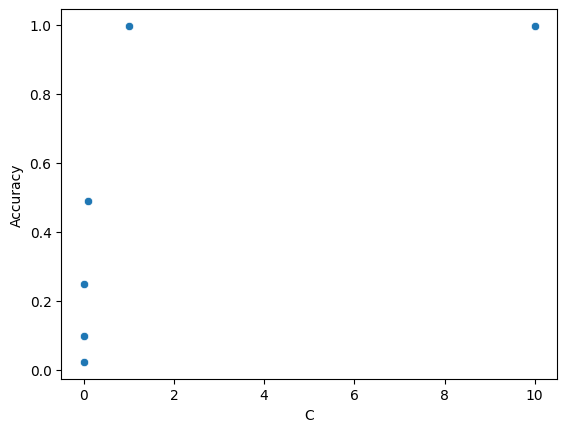

In [11]:
tests_to_run = [.0001, .001, .01, .1, 1.0, 10.0]
# Linear SVC Test
lsvc_results = pd.DataFrame(columns=['C', 'Accuracy', 'Standard Deviation'])
# Test different folds
with alive_bar(len(tests_to_run), force_tty=True) as bar:
        # Test different neighbors
        for i in tests_to_run:
            cvs = cross_val_score(SVC(C=i, kernel="linear"), X_sc, y, cv=10, n_jobs=-1)
            mean: float = float(np.mean(cvs))
            std: float = float(np.std(cvs))
            lsvc_results.loc[len(lsvc_results)] = [i, mean, std]
            bar()
print(lsvc_results)
print(lsvc_results.describe())
print(lsvc_results.iloc[[int(lsvc_results['Accuracy'].idxmax())]])
sns.scatterplot(data=lsvc_results,x='C',y='Accuracy')

# SVC
Change `gamma_to_test` to change the number of tests

Uses `tests_to_run` from before

|████████████████████████████████████████| 96/96 [100%] in 50:25.2 (0.03/s)     
          C  Gamma  Accuracy  Standard Deviation
0    0.0001    0.0    0.0226             0.00049
1    0.0001    1.0    0.0226             0.00049
2    0.0001    2.0    0.0226             0.00049
3    0.0001    3.0    0.0226             0.00049
4    0.0001    4.0    0.0226             0.00049
..      ...    ...       ...                 ...
91  10.0000   11.0    0.0226             0.00049
92  10.0000   12.0    0.0226             0.00049
93  10.0000   13.0    0.0226             0.00049
94  10.0000   14.0    0.0226             0.00049
95  10.0000   15.0    0.0226             0.00049

[96 rows x 4 columns]
               C      Gamma      Accuracy  Standard Deviation
count  96.000000  96.000000  9.600000e+01        9.600000e+01
mean    1.851850   7.500000  2.260000e-02        4.898979e-04
std     3.680595   4.633971  6.975319e-18        1.089894e-19
min     0.000100   0.000000  2.260000e-02        4.898979e-0

<Axes: xlabel='Gamma', ylabel='Accuracy'>

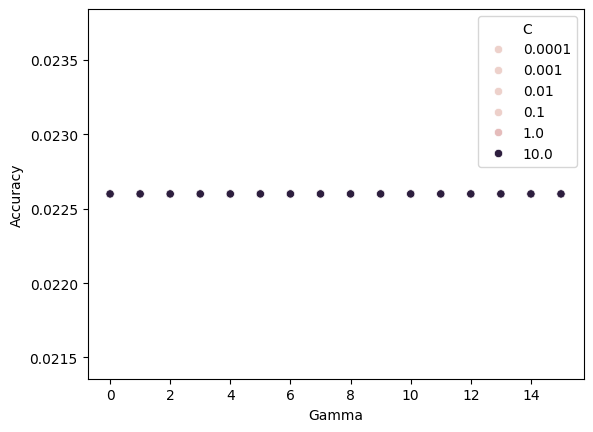

In [12]:
gamma_to_test: int = 16
# SVC Test
svc_results = pd.DataFrame(columns=['C', 'Gamma', 'Accuracy', 'Standard Deviation'])
# Test different folds
with alive_bar(len(tests_to_run)*gamma_to_test, force_tty=True) as bar:
    for i in tests_to_run:
        for k in range(gamma_to_test):
            cvs = cross_val_score(SVC(C=i, gamma=gamma_to_test), X_sc, y, cv=10, n_jobs=-1)
            mean: float = float(np.mean(cvs))
            std: float = float(np.std(cvs))
            svc_results.loc[len(svc_results)] = [i, k, mean, std]
            bar()
print(svc_results)
print(svc_results.describe())
print(svc_results.iloc[[int(svc_results['Accuracy'].idxmax())]])
sns.scatterplot(data=svc_results,x='Gamma',hue='C',y='Accuracy')

|████████████████████████████████████████| 256/256 [100%] in 2:43.7 (1.56/s)    
     depth  Accuracy  Standard Deviation
0      1.0    0.0426            0.000490
1      2.0    0.0852            0.001077
2      3.0    0.1653            0.001487
3      4.0    0.2428            0.001166
4      5.0    0.3246            0.001625
..     ...       ...                 ...
251  252.0    1.0000            0.000000
252  253.0    1.0000            0.000000
253  254.0    1.0000            0.000000
254  255.0    1.0000            0.000000
255  256.0    1.0000            0.000000

[256 rows x 3 columns]
            depth    Accuracy  Standard Deviation
count  256.000000  256.000000          256.000000
mean   128.500000    0.977661            0.000048
std     74.045031    0.124741            0.000237
min      1.000000    0.042600            0.000000
25%     64.750000    1.000000            0.000000
50%    128.500000    1.000000            0.000000
75%    192.250000    1.000000            0.000000
max

<Axes: xlabel='depth', ylabel='Accuracy'>

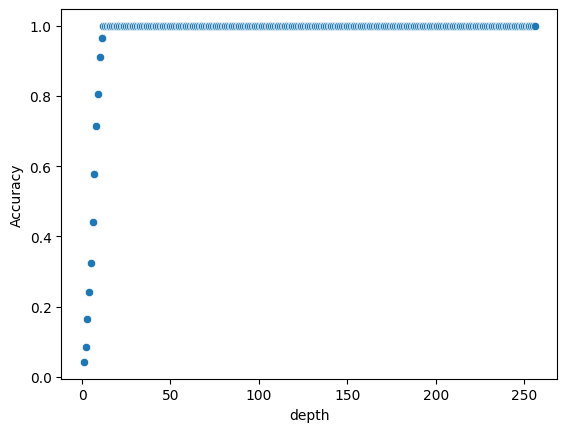

In [13]:
depth: int = 256
# Tree Test
dtree_results = pd.DataFrame(columns=['depth', 'Accuracy', 'Standard Deviation'])
# Test different folds
with alive_bar(depth, force_tty=True) as bar:
    for i in range(1, depth+1):
        cvs = cross_val_score(DTree(max_depth=i), X, y, cv=10, n_jobs=-1)
        mean: float = float(np.mean(cvs))
        std: float = float(np.std(cvs))
        dtree_results.loc[len(dtree_results)] = [i, mean, std]
        bar()
print(dtree_results)
print(dtree_results.describe())
print(dtree_results.iloc[[int(dtree_results['Accuracy'].idxmax())]])
sns.scatterplot(data=dtree_results,x='depth',y='Accuracy')

|████████████████████████████████████████| 512/512 [100%] in 3:23.7 (2.51/s)    
     estimators  features  Accuracy  Standard Deviation
0           1.0       1.0    0.0229            0.006759
1           1.0       2.0    0.0214            0.004104
2           1.0       3.0    0.0230            0.007707
3           1.0       4.0    0.0206            0.002059
4           1.0       5.0    0.0208            0.002638
..          ...       ...       ...                 ...
507        64.0       4.0    0.0397            0.018325
508        64.0       5.0    0.0509            0.020969
509        64.0       6.0    0.0409            0.017913
510        64.0       7.0    0.0419            0.018646
511        64.0       8.0    0.0437            0.013305

[512 rows x 4 columns]
       estimators    features    Accuracy  Standard Deviation
count   512.00000  512.000000  512.000000          512.000000
mean     32.50000    4.500000    0.033763            0.013025
std      18.49102    2.293529    0.00

<Axes: xlabel='estimators', ylabel='Accuracy'>

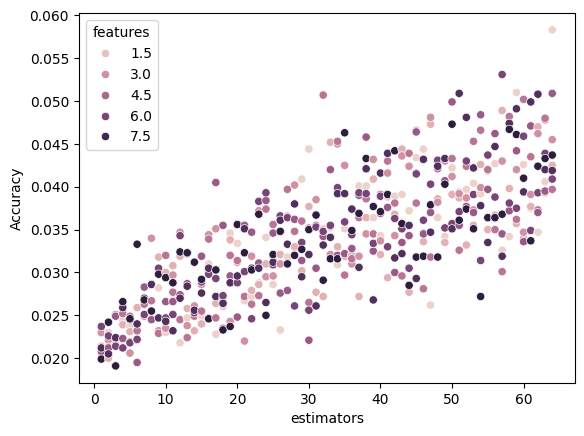

In [14]:
estimators: int = 64
features: int = 8
# Tree Test
rforest_results = pd.DataFrame(columns=['estimators', 'features', 'Accuracy', 'Standard Deviation'])
# Test different folds
with alive_bar(estimators*features, force_tty=True) as bar:
    for o in range(1, estimators+1):
        for u in range(1, features+1):
            cvs = cross_val_score(RandomForestClassifier(max_depth=1, n_estimators=o, max_features=1), X_sc, y, cv=10, n_jobs=-1)
            mean: float = float(np.mean(cvs))
            std: float = float(np.std(cvs))
            rforest_results.loc[len(rforest_results)] = [o, u, mean, std]
            bar()
print(rforest_results)
print(rforest_results.describe())
print(rforest_results.iloc[[int(rforest_results['Accuracy'].idxmax())]])
sns.scatterplot(data=rforest_results,x='estimators',hue='features',y='Accuracy')

|████████████████████████████████████████| 16/16 [100%] in 1:13.7 (0.21/s)      
    Alpha  Accuracy  Standard Deviation
0     1.0    0.0226            0.000490
1     2.0    0.0226            0.000490
2     3.0    0.0226            0.000490
3     4.0    0.0225            0.000500
4     5.0    0.0226            0.000490
5     6.0    0.0224            0.000490
6     7.0    0.0224            0.000663
7     8.0    0.0226            0.000490
8     9.0    0.0225            0.000500
9    10.0    0.0226            0.000490
10   11.0    0.0225            0.000500
11   12.0    0.0226            0.000490
12   13.0    0.0224            0.000490
13   14.0    0.0226            0.000490
14   15.0    0.0226            0.000490
15   16.0    0.0225            0.000500
           Alpha   Accuracy  Standard Deviation
count  16.000000  16.000000           16.000000
mean    8.500000   0.022537            0.000503
std     4.760952   0.000081            0.000043
min     1.000000   0.022400            0.000490

<Axes: xlabel='Alpha', ylabel='Accuracy'>

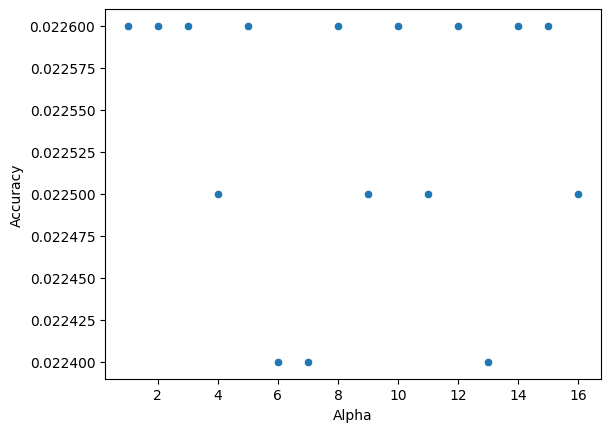

In [15]:
iterations: int = 32768
alpha: int = 16
# MLP Test
mlp_results = pd.DataFrame(columns=['Alpha', 'Accuracy', 'Standard Deviation'])
# Test different folds
with alive_bar(alpha, force_tty=True) as bar:
    for i in range(1, alpha+1):
        cvs = cross_val_score(MLP(alpha=o,max_iter=iterations), X_sc, y, cv=10, n_jobs=-1)
        mean: float = float(np.mean(cvs))
        std: float = float(np.std(cvs))
        mlp_results.loc[len(mlp_results)] = [i, mean, std]
        bar()
print(mlp_results)
print(mlp_results.describe())
print(mlp_results.iloc[[int(mlp_results['Accuracy'].idxmax())]])
sns.scatterplot(data=mlp_results,x='Alpha',y='Accuracy')

In [16]:
# Ada Test
cvs = cross_val_score(AdaBoostClassifier(), X_sc, y, cv=10, n_jobs=-1)
mean: float = float(np.mean(cvs))
std: float = float(np.std(cvs))
print("Mean:", str(mean), "| Std:", str(std))

Mean: 0.03490000000000001 | Std: 0.0003000000000000003


In [17]:
# Gaussian Test
cvs = cross_val_score(GaussianNB(), X_sc, y, cv=10, n_jobs=-1)
mean: float = float(np.mean(cvs))
std: float = float(np.std(cvs))
print("Mean:", str(mean), "| Std:", std)

Mean: 1.0 | Std: 0.0


In [18]:
# QDA Test
cvs = cross_val_score(QDA(reg_param=1), X_sc, y, cv=10, n_jobs=-1)
mean: float = float(np.mean(cvs))
std: float = float(np.std(cvs))
print("Mean:", str(mean), "| Std:", std)

ValueError: 
All the 10 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
7 fits failed with the following error:
Traceback (most recent call last):
  File "/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/discriminant_analysis.py", line 1122, in fit
    raise linalg.LinAlgError(
numpy.linalg.LinAlgError: The covariance matrix of class 6 is not full rank. When using `solver='sv

In [19]:
state: int = 512
solver = ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
# LReg Test
lreg_results = pd.DataFrame(columns=['Solver', 'State', 'Accuracy', 'Standard Deviation'])
# Test different folds
with alive_bar(state*len(solver), force_tty=True) as bar:
    for o in solver:
        for i in range(1, state+1):
            cvs = cross_val_score(LReg(random_state=state, solver=o), X_sc, y, cv=10, n_jobs=-1)
            mean: float = float(np.mean(cvs))
            std: float = float(np.std(cvs))
            lreg_results.loc[len(lreg_results)] = [o, i, mean, std]
            bar()
print(lreg_results)
print(lreg_results.describe())
print(lreg_results.iloc[[int(lreg_results['Accuracy'].idxmax())]])
sns.scatterplot(data=lreg_results,x='State',y='Accuracy',hue='Solver')

|██████▋⚠︎                                | (!) 512/3072 [17%] in 25:40.4 (0.33/s


ValueError: 
All the 10 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/tophat/solitaire-ai/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py", line 1208, in fit
    raise ValueError(
ValueError: The 'liblinear' solver does not support multiclass classification (n_classes >= 3). Either us

ValueError: Expected 'estimator' to be a binary classifier. Got 52 classes instead.

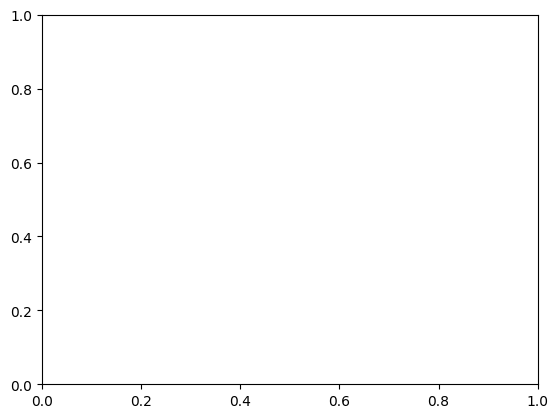

In [20]:
from sklearn.metrics import RocCurveDisplay, auc
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
X_train = X_sc
cv = StratifiedKFold(n_splits=5) # just to 5 fold
classifier = LogisticRegression(random_state=1, solver='lbfgs')
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)
fig, ax = plt.subplots()

# create and add ROC for each  fold
for i, (train, test) in enumerate(cv.split(X_train, y)): # iterator
    classifier.fit(X_train[train], y[train])
    viz = RocCurveDisplay.from_estimator(classifier, X_train[test], y[test],
                         name=f'ROC fold {i}',
                         alpha=0.3, lw=1, ax=ax)
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

# add curve for random guessing
ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
        label='Random guessing', alpha=.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

# add curve for mean scores
ax.plot(mean_fpr, mean_tpr, color='b',
        label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
        lw=2, alpha=.8)

# add curve for a perfect score
ax.plot([0, 0, 1],
        [0, 1, 1], linestyle=':', color='black', label='Perfect performance')

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                label=r'$\pm$ 1 std. dev.')

ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05],
       title="ROC Curve")
ax.legend(loc="lower right")
plt.show()